# Klasifikasi Tingkat Kematangan Buah Pisang
## K-Nearest Neighbor (KNN) dengan Optimasi Parameter via Particle Swarm Optimization (PSO)

Notebook ini mengklasifikasikan pisang ke **4 kelas kematangan**: `unripe` (mentah), `ripe` (matang), `overripe` (terlalu matang), `rotten` (busuk).

**Alur:** Gambar → Preprocessing & Segmentasi → Ekstraksi Fitur (warna + tekstur + bentuk) → Normalisasi → KNN baseline → PSO (cari K & bobot fitur optimal) → KNN+PSO → Evaluasi & Perbandingan.

> Dataset: Roboflow *Banana Ripeness Classification* (sudah dibagi `train`/`valid`/`test`, gambar 416×416, sudah diaugmentasi 3×).


## Blok 1 — Import Library & Konfigurasi
Semua pengaturan yang bisa diubah tim ada di sini (ukuran resize, daftar kelas, random seed, parameter PSO).

In [1]:
# Library pengolahan citra & numerik
import cv2
import numpy as np
import pandas as pd
import os, glob, time

# Tekstur (GLCM) & evaluasi
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ----- KONFIGURASI (boleh diubah tim) -----
IMG_SIZE      = 100          # ukuran resize gambar (px). Lebih kecil = lebih cepat
KELAS         = ['unripe', 'ripe', 'overripe', 'rotten']   # 4 kelas kematangan
RANDOM_STATE  = 42           # seed agar hasil bisa direproduksi
K_DEFAULT     = 5            # nilai K untuk KNN baseline (sebelum dioptimasi)
DATA_DIR      = '.'          # folder berisi train/ valid/ test/

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)
print("Library siap. Kelas:", KELAS)

Library siap. Kelas: ['unripe', 'ripe', 'overripe', 'rotten']


## Blok 2 — Preprocessing & Segmentasi Pisang

Background gambar beragam (putih, hitam, ubin) sehingga bisa mengacaukan rata-rata warna. Kita **pisahkan pisang dari background** dengan threshold **saturasi (Otsu)**: background cenderung pucat/abu (saturasi rendah), pisang berwarna jelas (saturasi tinggi).

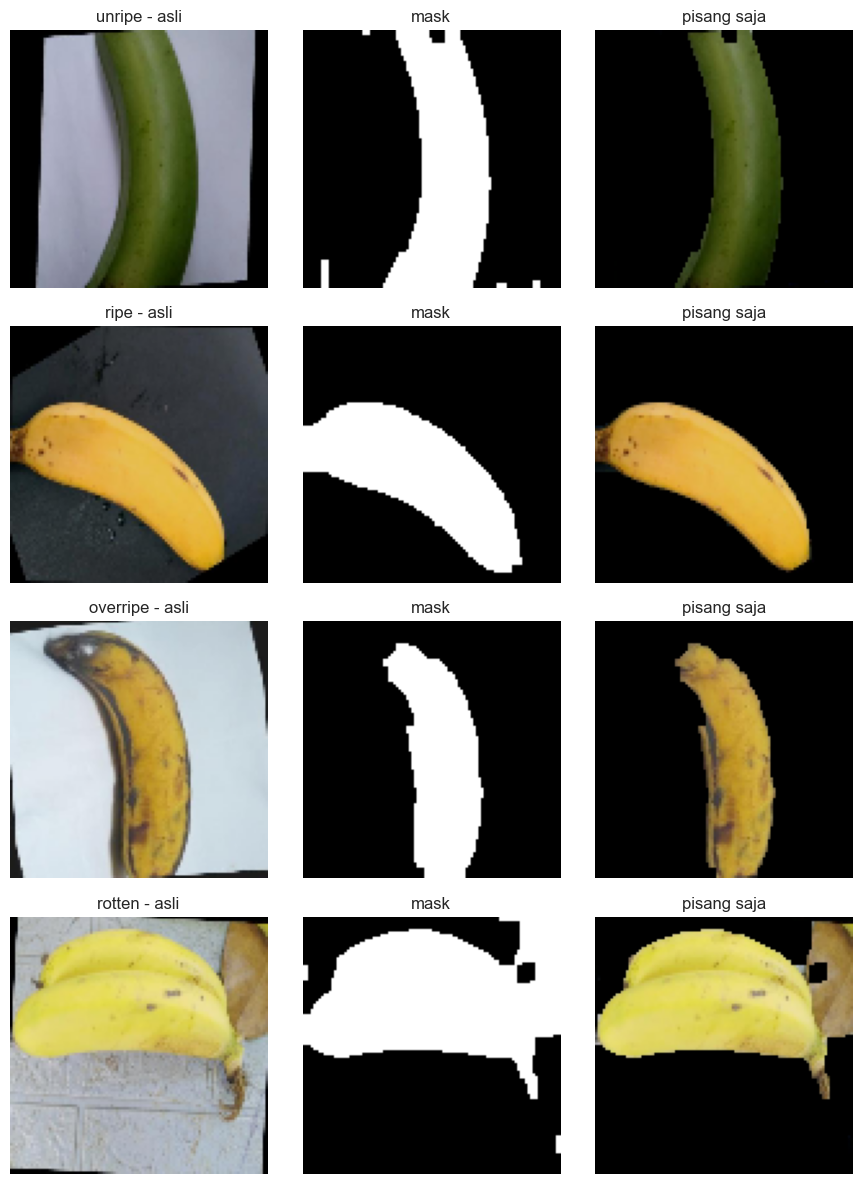

In [2]:
def segmentasi_pisang(img_bgr):
    """Buat mask (hitam-putih) yang menandai area pisang.
    Pakai Otsu pada channel Saturation (HSV). Kalau mask terlalu kecil
    (<5% area), anggap segmentasi gagal -> pakai seluruh gambar."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    _, mask = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)   # buang noise kecil
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)  # tutup lubang
    if mask.sum() / 255 < 0.05 * mask.size:
        mask = np.ones_like(mask) * 255
    return mask

# --- Demo segmentasi pada 1 gambar tiap kelas ---
fig, axes = plt.subplots(len(KELAS), 3, figsize=(9, 3 * len(KELAS)))
for i, cls in enumerate(KELAS):
    f = sorted(glob.glob(f'{DATA_DIR}/train/{cls}/*.jpg'))[0]
    img = cv2.resize(cv2.imread(f), (IMG_SIZE, IMG_SIZE))
    mask = segmentasi_pisang(img)
    hasil = cv2.bitwise_and(img, img, mask=mask)
    for ax, im, judul in zip(axes[i],
                             [img, cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), hasil],
                             [f'{cls} - asli', 'mask', 'pisang saja']):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(judul); ax.axis('off')
plt.tight_layout(); plt.show()

## Blok 3 — Ekstraksi Fitur

Dari tiap gambar diambil **9 fitur**:

| # | Fitur | Keterangan |
|---|-------|-----------|
| 1-3 | Mean R, G, B | rata-rata warna RGB (piksel pisang) |
| 4-6 | Mean H, S, V | rata-rata Hue/Saturation/Value |
| 7 | Contrast | kontras tekstur (GLCM) |
| 8 | Entropy | keacakan tekstur (GLCM) |
| 9 | Area | proporsi luas pisang terhadap gambar |

In [3]:
FITUR = ['mean_r', 'mean_g', 'mean_b', 'mean_h', 'mean_s', 'mean_v',
         'contrast', 'entropy', 'area']

def ekstrak_fitur(path):
    """Kembalikan list 9 fitur dari satu gambar."""
    img  = cv2.resize(cv2.imread(path), (IMG_SIZE, IMG_SIZE))
    mask = segmentasi_pisang(img)
    m    = mask > 0

    # 1-3) Warna RGB (rata-rata pada piksel pisang)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mean_r, mean_g, mean_b = rgb[:, :, 0][m].mean(), rgb[:, :, 1][m].mean(), rgb[:, :, 2][m].mean()

    # 4-6) Warna HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_h, mean_s, mean_v = hsv[:, :, 0][m].mean(), hsv[:, :, 1][m].mean(), hsv[:, :, 2][m].mean()

    # 7-8) Tekstur GLCM pada grayscale (dikuantisasi 8 level agar stabil)
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_q = (gray / 32).astype(np.uint8)
    glcm   = graycomatrix(gray_q, distances=[1], angles=[0], levels=8, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    p = glcm[:, :, 0, 0]
    entropy = -np.sum(p * np.log2(p + 1e-10))

    # 9) Bentuk: proporsi area pisang
    area = m.sum() / m.size
    return [mean_r, mean_g, mean_b, mean_h, mean_s, mean_v, contrast, entropy, area]

# uji 1 gambar
contoh = ekstrak_fitur(sorted(glob.glob(f'{DATA_DIR}/train/ripe/*.jpg'))[0])
print("Contoh fitur (ripe):", dict(zip(FITUR, np.round(contoh, 2))))

Contoh fitur (ripe): {'mean_r': np.float64(207.79), 'mean_g': np.float64(161.44), 'mean_b': np.float64(61.82), 'mean_h': np.float64(21.3), 'mean_s': np.float64(179.38), 'mean_v': np.float64(207.92), 'contrast': np.float64(0.18), 'entropy': np.float64(2.27), 'area': np.float64(0.27)}


### Ekstraksi seluruh dataset (dengan cache)

Ekstraksi 13k gambar memakan ~3 menit, jadi hasilnya **disimpan ke CSV**. Saat dijalankan ulang, notebook langsung membaca CSV (tidak ekstrak ulang). Hapus file `fitur_*.csv` kalau ingin ekstrak ulang.

In [4]:
def bangun_dataframe(split):
    """Ekstrak fitur semua gambar di folder split (train/valid/test) -> DataFrame.
    Hasil di-cache ke fitur_{split}.csv."""
    cache = f'fitur_{split}.csv'
    if os.path.exists(cache):
        print(f'[cache] muat {cache}')
        return pd.read_csv(cache)

    baris = []
    for cls in KELAS:
        files = glob.glob(f'{DATA_DIR}/{split}/{cls}/*.jpg')
        for f in tqdm(files, desc=f'{split}/{cls}', leave=False):
            try:
                baris.append(ekstrak_fitur(f) + [cls])
            except Exception as e:
                print('lewati', f, e)
    df = pd.DataFrame(baris, columns=FITUR + ['label'])
    df.to_csv(cache, index=False)
    print(f'[simpan] {cache}  shape={df.shape}')
    return df

t0 = time.time()
df_train = bangun_dataframe('train')
df_valid = bangun_dataframe('valid')
df_test  = bangun_dataframe('test')
print(f'Selesai dalam {time.time()-t0:.1f}s')
print('train:', df_train.shape, '| valid:', df_valid.shape, '| test:', df_test.shape)

[cache] muat fitur_train.csv
[cache] muat fitur_valid.csv
[cache] muat fitur_test.csv
Selesai dalam 0.0s
train: (11793, 10) | valid: (1123, 10) | test: (562, 10)


## Blok 4 — Eksplorasi Data Fitur
Lihat sampel fitur, jumlah data per kelas, dan sebaran tiap fitur antar kelas.

Sampel data train:


,mean_r,mean_g,mean_b,mean_h,mean_s,mean_v,contrast,entropy,area,label
0,66.684191,81.055112,25.289340,38.518129,185.485859,81.096084,0.540202,3.201402,0.2758,unripe
1,104.625908,121.424914,59.766527,38.995415,133.387467,121.502102,0.300808,2.905093,0.2617,unripe
2,116.973455,137.913538,67.780812,39.048540,133.048540,137.957148,0.760808,3.134842,0.2637,unripe
3,86.029392,106.635073,44.843791,40.058124,154.941546,106.784346,0.431111,3.627004,0.3028,unripe
4,110.223454,120.802083,62.827621,37.515121,129.526210,121.177419,0.493838,3.673007,0.2976,unripe



Jumlah gambar per kelas (train):
label
rotten      4020
ripe        3522
overripe    2349
unripe      1902
Name: count, dtype: int64


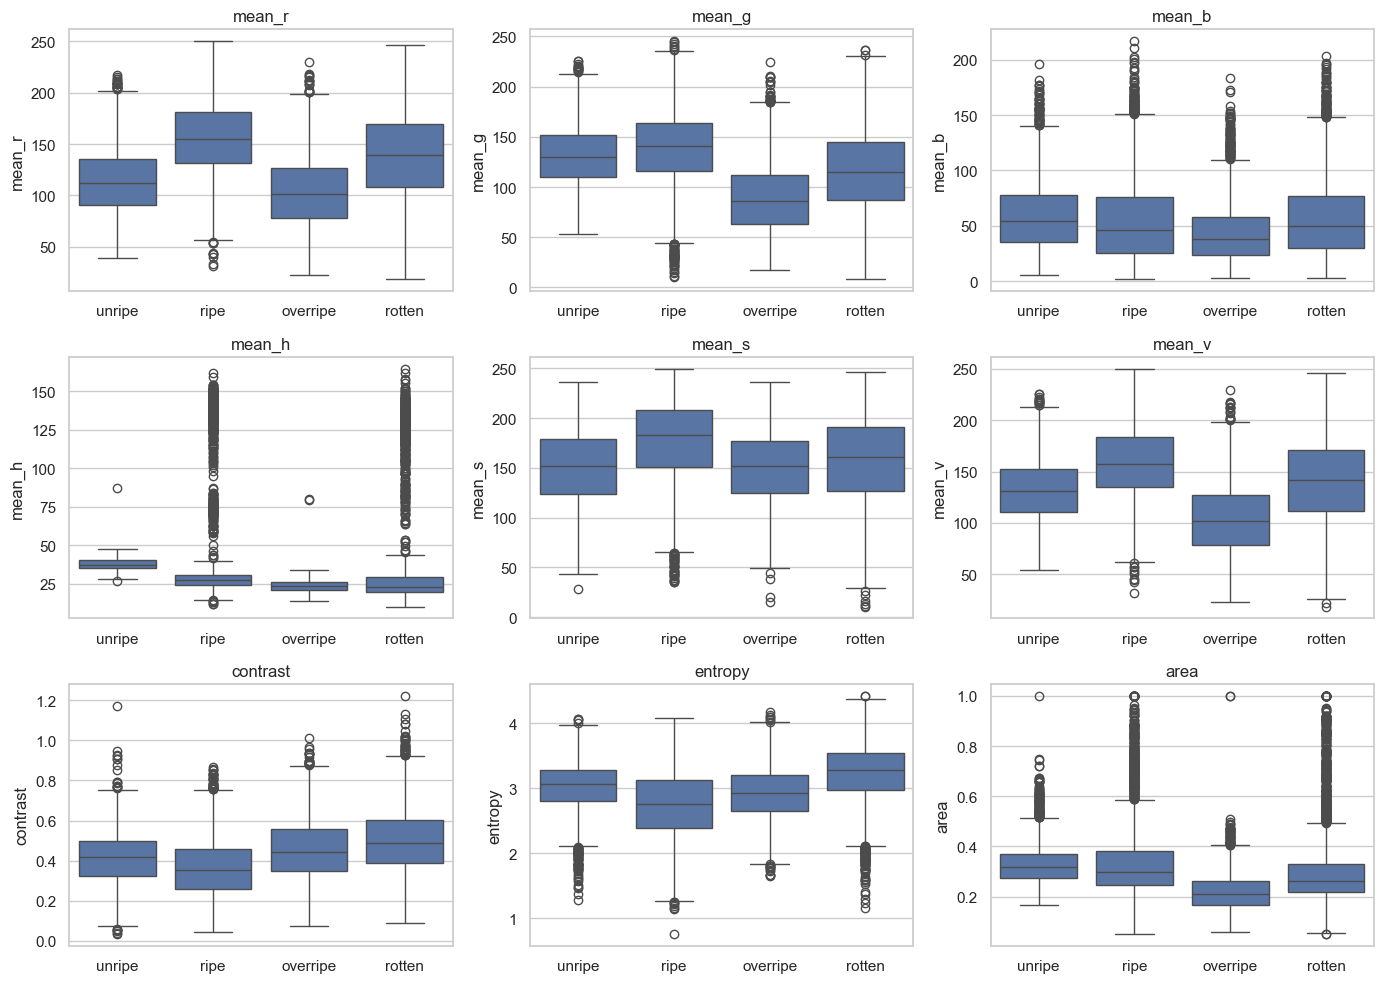

In [5]:
print("Sampel data train:")
display(df_train.head())
print("\nJumlah gambar per kelas (train):")
print(df_train['label'].value_counts())

# Boxplot sebaran tiap fitur per kelas -> melihat fitur mana yang membedakan kelas
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, kol in zip(axes.ravel(), FITUR):
    sns.boxplot(data=df_train, x='label', y=kol, ax=ax, order=KELAS)
    ax.set_title(kol); ax.set_xlabel('')
plt.tight_layout(); plt.show()

## Blok 5 — Normalisasi Fitur & Siapkan X, y

Skala tiap fitur berbeda (Hue 0-179, area 0-1). KNN berbasis jarak, jadi fitur harus dinormalisasi ke rentang 0-1 dengan **MinMaxScaler**. Scaler **di-fit hanya pada data train**, lalu dipakai untuk valid & test (mencegah kebocoran informasi).

In [6]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(df_train[FITUR])     # fit hanya di train
X_valid = scaler.transform(df_valid[FITUR])
X_test  = scaler.transform(df_test[FITUR])

# Ubah label teks -> angka
le = LabelEncoder().fit(KELAS)
y_train = le.transform(df_train['label'])
y_valid = le.transform(df_valid['label'])
y_test  = le.transform(df_test['label'])

print("X_train:", X_train.shape, "| X_valid:", X_valid.shape, "| X_test:", X_test.shape)
print("Urutan label:", list(le.classes_))

X_train: (11793, 9) | X_valid: (1123, 9) | X_test: (562, 9)
Urutan label: [np.str_('overripe'), np.str_('ripe'), np.str_('rotten'), np.str_('unripe')]


## Blok 6 — KNN Baseline (K=5, tanpa optimasi)
Model pembanding: KNN dengan K default dan semua fitur berbobot sama.

In [7]:
knn_base = KNeighborsClassifier(n_neighbors=K_DEFAULT)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
print(f"KNN Baseline (K={K_DEFAULT})  ->  Akurasi test: {acc_base:.4f}")
print("\nLaporan klasifikasi:")
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

KNN Baseline (K=5)  ->  Akurasi test: 0.7491

Laporan klasifikasi:
              precision    recall  f1-score   support

    overripe       0.68      0.83      0.75       113
        ripe       0.78      0.82      0.80       154
      rotten       0.70      0.55      0.62       185
      unripe       0.85      0.90      0.88       110

    accuracy                           0.75       562
   macro avg       0.75      0.78      0.76       562
weighted avg       0.75      0.75      0.74       562



### Bukti: KNN training itu instan, prediksinya yang "bekerja"
KNN adalah *lazy learner* — saat `.fit()` ia hanya **menyimpan data** dan tidak menghitung apa-apa, jadi training-nya nyaris nol. Kerja beratnya (menghitung jarak ke semua data training) baru terjadi saat `.predict()`. Di sel berikut dipakai `algorithm='brute'` agar perbedaan ini terlihat jelas.

In [8]:
import time

# Pakai algorithm='brute' = KNN 'murni': fit hanya menyimpan data,
# semua jarak baru dihitung saat predict. (Default sklearn 'auto' membangun
# KD-tree saat fit, jadi fit-nya tidak benar-benar nol.)
knn_demo = KNeighborsClassifier(n_neighbors=K_DEFAULT, algorithm='brute')

# Waktu TRAINING (.fit) -> cuma menyimpan data ke memori
t0 = time.perf_counter()
knn_demo.fit(X_train, y_train)
t_fit = time.perf_counter() - t0

# Waktu PREDIKSI (.predict) -> hitung jarak tiap data ke SEMUA data training
t0 = time.perf_counter()
knn_demo.predict(X_train)   # prediksi 11.793 gambar sekaligus
t_pred = time.perf_counter() - t0

print(f"Data training        : {X_train.shape[0]} baris x {X_train.shape[1]} fitur")
print(f".fit()    (training) : {t_fit*1000:8.2f} ms   <- cuma menyimpan data (nyaris nol)")
print(f".predict() ({X_train.shape[0]} gbr): {t_pred*1000:8.2f} ms   <- menghitung jarak ke semua data")
print()
print(f"Prediksi sekitar {t_pred/max(t_fit,1e-9):.0f}x lebih lama daripada training.")
print("=> KNN tidak benar-benar belajar saat fit; kerja beratnya ditunda ke saat predict.")


Data training        : 11793 baris x 9 fitur
.fit()    (training) :     1.91 ms   <- cuma menyimpan data (nyaris nol)
.predict() (11793 gbr):  1518.30 ms   <- menghitung jarak ke semua data

Prediksi sekitar 797x lebih lama daripada training.
=> KNN tidak benar-benar belajar saat fit; kerja beratnya ditunda ke saat predict.


## Blok 7 — Akurasi per Nilai K (K = 1..20)
Menunjukkan bahwa nilai K mempengaruhi akurasi — motivasi kenapa K perlu dioptimasi. Akurasi diukur pada set **valid**.

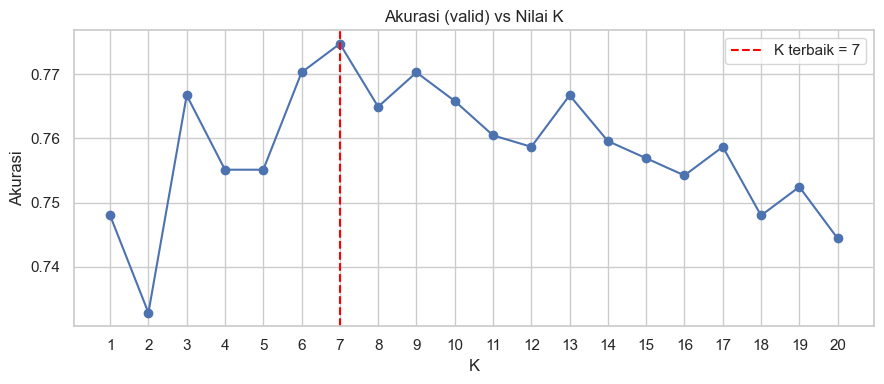

K terbaik (grid search di valid): 7  ->  akurasi 0.7747


In [9]:
K_range = range(1, 21)
akurasi_per_k = []
for k in K_range:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    akurasi_per_k.append(accuracy_score(y_valid, m.predict(X_valid)))

k_terbaik_grid = K_range[int(np.argmax(akurasi_per_k))]
plt.figure(figsize=(9, 4))
plt.plot(list(K_range), akurasi_per_k, marker='o')
plt.axvline(k_terbaik_grid, color='red', ls='--', label=f'K terbaik = {k_terbaik_grid}')
plt.title('Akurasi (valid) vs Nilai K'); plt.xlabel('K'); plt.ylabel('Akurasi')
plt.xticks(list(K_range)); plt.legend(); plt.tight_layout(); plt.show()
print(f"K terbaik (grid search di valid): {k_terbaik_grid}  ->  akurasi {max(akurasi_per_k):.4f}")

## Blok 8 — Particle Swarm Optimization (PSO) — implementasi manual

PSO meniru perilaku kawanan burung mencari makan. Tiap **partikel** adalah satu kandidat solusi yang "terbang" di ruang pencarian, dipandu oleh:
- **pbest** — posisi terbaik yang pernah ditemukan partikel itu sendiri (kognitif, c1)
- **gbest** — posisi terbaik seluruh kawanan (sosial, c2)

Yang dioptimasi PSO di sini = **nilai K (1-20)** + **bobot 9 fitur** (0-1). Bobot menskalakan tiap fitur sebelum hitung jarak KNN, jadi PSO bisa "mematikan" fitur yang mengganggu dan menonjolkan fitur penting.

**Fungsi fitness = akurasi KNN pada set valid** (semakin tinggi semakin baik).

In [10]:
# Parameter PSO (boleh diubah tim)
N_PARTIKEL = 25
N_ITERASI  = 60
W_MAX, W_MIN = 0.9, 0.4     # inertia weight menurun 0.9 -> 0.4
C1, C2 = 2.0, 2.0           # koefisien kognitif & sosial

DIM = 1 + len(FITUR)        # [K, w1..w9] = 10 dimensi
# batas tiap dimensi: dim-0 = K (1..20), sisanya = bobot (0..1)
batas_bawah = np.array([1.0]  + [0.0] * len(FITUR))
batas_atas  = np.array([20.0] + [1.0] * len(FITUR))

def fitness(posisi):
    """Akurasi KNN di valid untuk satu posisi partikel [K, bobot...]."""
    k = int(np.clip(round(posisi[0]), 1, 20))
    w = np.clip(posisi[1:], 0, 1)
    if w.sum() == 0:        # hindari semua bobot nol
        return 0.0
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train * w, y_train)            # skalakan fitur dengan bobot
    return accuracy_score(y_valid, m.predict(X_valid * w))

def jalankan_pso():
    rng = np.random.default_rng(RANDOM_STATE)
    # inisialisasi posisi & kecepatan partikel
    pos = rng.uniform(batas_bawah, batas_atas, size=(N_PARTIKEL, DIM))
    vel = np.zeros((N_PARTIKEL, DIM))

    pbest_pos = pos.copy()
    pbest_fit = np.array([fitness(p) for p in pos])
    g_idx = pbest_fit.argmax()
    gbest_pos, gbest_fit = pbest_pos[g_idx].copy(), pbest_fit[g_idx]

    riwayat = [gbest_fit]      # untuk grafik konvergensi
    for it in range(N_ITERASI):
        w_inertia = W_MAX - (W_MAX - W_MIN) * it / N_ITERASI   # inertia menurun
        for i in range(N_PARTIKEL):
            r1, r2 = rng.random(DIM), rng.random(DIM)
            vel[i] = (w_inertia * vel[i]
                      + C1 * r1 * (pbest_pos[i] - pos[i])      # tarik ke pbest
                      + C2 * r2 * (gbest_pos    - pos[i]))     # tarik ke gbest
            pos[i] = np.clip(pos[i] + vel[i], batas_bawah, batas_atas)
            f = fitness(pos[i])
            if f > pbest_fit[i]:                               # update pbest
                pbest_fit[i], pbest_pos[i] = f, pos[i].copy()
                if f > gbest_fit:                              # update gbest
                    gbest_fit, gbest_pos = f, pos[i].copy()
        riwayat.append(gbest_fit)
        if (it + 1) % 10 == 0:
            print(f'  iterasi {it+1:3d}/{N_ITERASI}  gbest fitness (akurasi valid) = {gbest_fit:.4f}')
    return gbest_pos, gbest_fit, riwayat

print(f"Menjalankan PSO: {N_PARTIKEL} partikel x {N_ITERASI} iterasi ...")
t0 = time.time()
gbest_pos, gbest_fit, riwayat = jalankan_pso()
print(f"Selesai dalam {time.time()-t0:.1f}s")

K_optimal = int(np.clip(round(gbest_pos[0]), 1, 20))
bobot_optimal = np.clip(gbest_pos[1:], 0, 1)
print(f"\nK optimal (PSO)   : {K_optimal}")
print(f"Akurasi valid     : {gbest_fit:.4f}")
print("Bobot fitur optimal:")
for nama, b in zip(FITUR, bobot_optimal):
    print(f"  {nama:9}: {b:.3f}")

Menjalankan PSO: 25 partikel x 60 iterasi ...
  iterasi  10/60  gbest fitness (akurasi valid) = 0.8326
  iterasi  20/60  gbest fitness (akurasi valid) = 0.8388
  iterasi  30/60  gbest fitness (akurasi valid) = 0.8442
  iterasi  40/60  gbest fitness (akurasi valid) = 0.8442
  iterasi  50/60  gbest fitness (akurasi valid) = 0.8442
  iterasi  60/60  gbest fitness (akurasi valid) = 0.8442
Selesai dalam 37.8s

K optimal (PSO)   : 19
Akurasi valid     : 0.8442
Bobot fitur optimal:
  mean_r   : 1.000
  mean_g   : 0.000
  mean_b   : 1.000
  mean_h   : 1.000
  mean_s   : 0.000
  mean_v   : 0.745
  contrast : 0.000
  entropy  : 0.196
  area     : 1.000


## Blok 9 — Grafik Konvergensi PSO
Memperlihatkan akurasi terbaik (gbest) meningkat lalu stabil seiring iterasi.

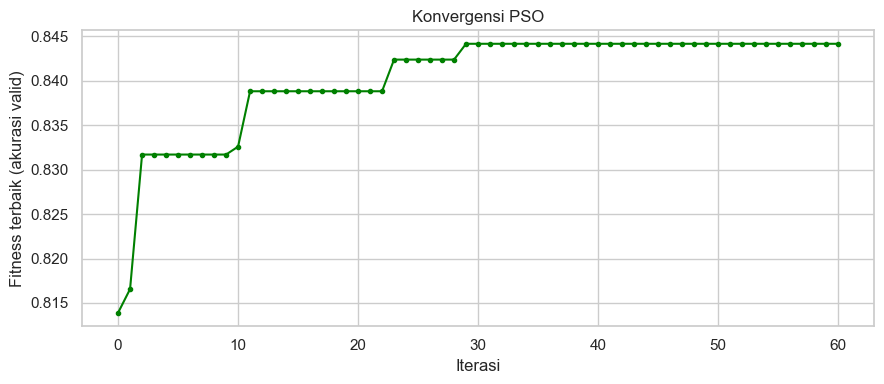

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(riwayat, marker='.', color='green')
plt.title('Konvergensi PSO'); plt.xlabel('Iterasi')
plt.ylabel('Fitness terbaik (akurasi valid)')
plt.tight_layout(); plt.show()

## Blok 10 — KNN + PSO (model final) & Evaluasi di Test
Latih KNN dengan **K dan bobot fitur hasil PSO**, lalu evaluasi pada set **test** (data yang belum pernah dilihat).

In [12]:
knn_pso = KNeighborsClassifier(n_neighbors=K_optimal)
knn_pso.fit(X_train * bobot_optimal, y_train)
y_pred_pso = knn_pso.predict(X_test * bobot_optimal)

acc_pso = accuracy_score(y_test, y_pred_pso)
print(f"KNN + PSO (K={K_optimal})  ->  Akurasi test: {acc_pso:.4f}")
print("\nLaporan klasifikasi:")
print(classification_report(y_test, y_pred_pso, target_names=le.classes_))

KNN + PSO (K=19)  ->  Akurasi test: 0.8238

Laporan klasifikasi:
              precision    recall  f1-score   support

    overripe       0.77      0.86      0.81       113
        ripe       0.82      0.88      0.85       154
      rotten       0.80      0.71      0.75       185
      unripe       0.93      0.91      0.92       110

    accuracy                           0.82       562
   macro avg       0.83      0.84      0.83       562
weighted avg       0.82      0.82      0.82       562



## Blok 11 — Tabel Perbandingan & Confusion Matrix
Bandingkan KNN biasa vs KNN+PSO pada semua metrik, lalu lihat confusion matrix keduanya.

=== PERBANDINGAN KNN BIASA vs KNN + PSO (set test) ===


,KNN Biasa (K=5),KNN + PSO (K=19),Selisih
Accuracy,0.7491,0.8238,0.0747
Precision,0.7527,0.8294,0.0767
Recall,0.7753,0.8381,0.0628
F1,0.7596,0.8321,0.0725


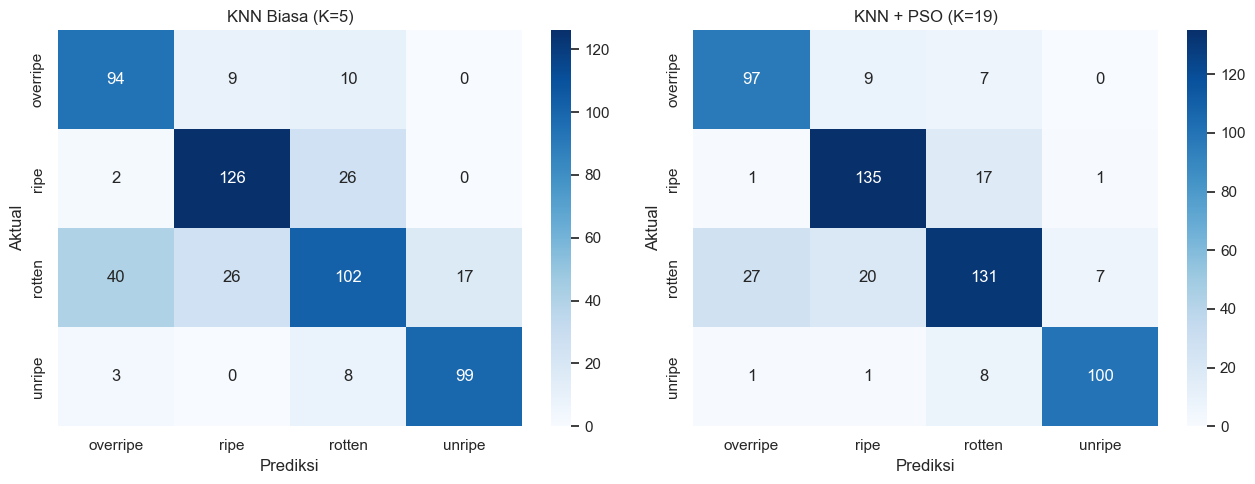

In [13]:
def metrik(y_true, y_pred):
    return dict(
        Accuracy  = accuracy_score(y_true, y_pred),
        Precision = precision_score(y_true, y_pred, average='macro', zero_division=0),
        Recall    = recall_score(y_true, y_pred, average='macro', zero_division=0),
        F1        = f1_score(y_true, y_pred, average='macro', zero_division=0),
    )

tabel = pd.DataFrame({
    f'KNN Biasa (K={K_DEFAULT})':  metrik(y_test, y_pred_base),
    f'KNN + PSO (K={K_optimal})':  metrik(y_test, y_pred_pso),
}).round(4)
tabel['Selisih'] = (tabel.iloc[:, 1] - tabel.iloc[:, 0]).round(4)
print("=== PERBANDINGAN KNN BIASA vs KNN + PSO (set test) ===")
display(tabel)

# Confusion matrix berdampingan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, yp, judul in zip(axes, [y_pred_base, y_pred_pso],
                         [f'KNN Biasa (K={K_DEFAULT})', f'KNN + PSO (K={K_optimal})']):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(judul); ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout(); plt.show()

## Blok 12 — Prediksi Gambar Pisang Baru (Inference)
Fungsi siap pakai untuk memprediksi kematangan satu gambar pisang baru.

In [ ]:
def prediksi_gambar(path, tampilkan=True):
    """Prediksi kelas kematangan satu gambar memakai model KNN+PSO."""
    fitur = np.array(ekstrak_fitur(path)).reshape(1, -1)
    fitur = scaler.transform(fitur) * bobot_optimal        # normalisasi + bobot PSO
    proba = knn_pso.predict_proba(fitur)[0]
    kelas = le.classes_[proba.argmax()]
    if tampilkan:
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(4, 4)); plt.imshow(img); plt.axis('off')
        plt.title(f'Prediksi: {kelas} ({proba.max()*100:.1f}%)'); plt.show()
    return kelas, dict(zip(le.classes_, np.round(proba, 3)))

# contoh: ambil 1 gambar test acak tiap kelas
for cls in KELAS:
    f = sorted(glob.glob(f'{DATA_DIR}/test/{cls}/*.jpg'))[0]
    pred, proba = prediksi_gambar(f, tampilkan=False)
    print(f'asli={cls:9} -> prediksi={pred:9} | {proba}')

asli=unripe    -> prediksi=unripe    | {np.str_('overripe'): np.float64(0.0), np.str_('ripe'): np.float64(0.0), np.str_('rotten'): np.float64(0.053), np.str_('unripe'): np.float64(0.947)}
asli=ripe      -> prediksi=ripe      | {np.str_('overripe'): np.float64(0.0), np.str_('ripe'): np.float64(0.789), np.str_('rotten'): np.float64(0.211), np.str_('unripe'): np.float64(0.0)}
asli=overripe  -> prediksi=ripe      | {np.str_('overripe'): np.float64(0.263), np.str_('ripe'): np.float64(0.579), np.str_('rotten'): np.float64(0.158), np.str_('unripe'): np.float64(0.0)}
asli=rotten    -> prediksi=rotten    | {np.str_('overripe'): np.float64(0.0), np.str_('ripe'): np.float64(0.368), np.str_('rotten'): np.float64(0.632), np.str_('unripe'): np.float64(0.0)}


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## Blok 13 — Kesimpulan

Jalankan sel di bawah untuk menyimpulkan otomatis apakah PSO meningkatkan akurasi.

In [15]:
selisih = acc_pso - acc_base
print("="*55)
print(f"  KNN Biasa (K={K_DEFAULT})   : akurasi test = {acc_base:.4f}")
print(f"  KNN + PSO (K={K_optimal})   : akurasi test = {acc_pso:.4f}")
print(f"  Peningkatan          : {selisih:+.4f} ({selisih*100:+.2f}%)")
print("="*55)
if selisih > 0:
    print(f"KESIMPULAN: PSO BERHASIL meningkatkan akurasi sebesar {selisih*100:.2f}%.")
    print("PSO menemukan kombinasi nilai K dan bobot fitur yang lebih baik")
    print("daripada KNN biasa (K default, bobot fitur seragam).")
else:
    print("KESIMPULAN: Pada percobaan ini PSO belum meningkatkan akurasi.")
    print("Coba ubah parameter PSO (jumlah partikel/iterasi) atau set fitur.")

  KNN Biasa (K=5)   : akurasi test = 0.7491
  KNN + PSO (K=19)   : akurasi test = 0.8238
  Peningkatan          : +0.0747 (+7.47%)
KESIMPULAN: PSO BERHASIL meningkatkan akurasi sebesar 7.47%.
PSO menemukan kombinasi nilai K dan bobot fitur yang lebih baik
daripada KNN biasa (K default, bobot fitur seragam).
